# E5 · Historical measurement and the observation window

**Optional decision:** How much does measured price variability depend on which observations we choose? Read M3 and M4 first; allow 10–15 minutes. The entire history here is **synthetic**, with hypothetical monthly prices of 10, 11, 10, 11, 10, 11, 10 and 20 USD/GPU-hour from January through August 2025. These are not observed compute-market quotes.

Assume one unchanged product definition, provider, region and service period convention across observations. That comparability is a teaching assumption, not something numerical validation can prove. A price series mixing different products would answer a different question.

We measure adjacent-month log changes and their sample standard deviation. This is a historical-measurement method applied to invented data, not a price forecast, stress probability or automatic calibration for M6's valuation tree.

In [1]:
# Install the teaching package from GitHub when running in Google Colab.
# Local Jupyter uses the repository's existing environment.
import subprocess
import sys

if "google.colab" in sys.modules:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "liquid-compute[colab] @ git+https://github.com/zach189/education.git@main",
        ]
    )
    from google.colab import output

    output.enable_custom_widget_manager()

In [2]:
from math import log, sqrt

from IPython.display import display

from liquid_compute.education import (
    explore_observation_window,
    plot_observation_window,
    show_finance_table,
)
from liquid_compute.risk_statistics import (
    MonthlyPrice,
    monthly_log_returns,
    sample_volatility,
)

prices = (10, 11, 10, 11, 10, 11, 10, 20)
january = 2025 * 12
observations = tuple(MonthlyPrice(january + i, price) for i, price in enumerate(prices))


def month_label(index):
    return f"{index // 12:04d}-{index % 12 + 1:02d}"


show_finance_table(
    ["Synthetic observation month", "USD/GPU-hour"],
    [
        [month_label(row.month_index), row.price_usd_per_gpu_hour]
        for row in observations
    ],
)

| Synthetic observation month | USD/GPU-hour |
| --- | --- |
| 2025-01 | 10.00 |
| 2025-02 | 11.00 |
| 2025-03 | 10.00 |
| 2025-04 | 11.00 |
| 2025-05 | 10.00 |
| 2025-06 | 11.00 |
| 2025-07 | 10.00 |
| 2025-08 | 20.00 |

## Calculate two returns explicitly

The January-to-February change is ln(11/10) = 0.0953102; February-to-March is ln(10/11) = −0.0953102. Price levels have USD/GPU-hour units; these log ratios are dimensionless. They are log changes rather than ordinary percentage returns.

The final 10-to-20 move has log change ln(2) = 0.6931472, although its simple percentage change is 100%. The different numbers reflect different definitions, not disagreement about the starting and ending prices. Do not mix the two return conventions within one sample.

In [3]:
first_change = log(11 / 10)
second_change = log(10 / 11)
jump_change = log(20 / 10)
show_finance_table(
    ["Direct change", "Log return"],
    [
        ["January to February", first_change],
        ["February to March", second_change],
        ["July to August", jump_change],
    ],
)
print(f"First two log changes: {first_change:.7f}, {second_change:.7f}")

| Direct change | Log return |
| --- | --- |
| January to February | 0.10 |
| February to March | -0.10 |
| July to August | 0.69 |

First two log changes: 0.0953102, -0.0953102


## Show the sample calculation before the helper

Seven adjacent-month changes come from eight prices. Compute their mean, squared deviations, and variance using the denominator n−1 = 6. Then take the square root. [NIST's Measures of Scale](https://www.itl.nist.gov/div898/handbook/eda/section3/eda356.htm) defines this sample variance and standard deviation.

Using n instead would compute a different statistic. We do not round individual returns before measuring dispersion. The shared helper reports counts and unavailable results explicitly; fewer than two valid returns is insufficient history, not evidence of zero risk.

In [4]:
direct_returns = [log(after / before) for before, after in zip(prices, prices[1:])]
mean_return = sum(direct_returns) / len(direct_returns)
squared_deviations = sum((value - mean_return) ** 2 for value in direct_returns)
direct_sample_sd = sqrt(squared_deviations / (len(direct_returns) - 1))
returns = monthly_log_returns(observations)
whole = sample_volatility([r.log_change for r in returns])
show_finance_table(
    ["Calculation", "Value"],
    [
        ["Valid changes n", len(direct_returns)],
        ["Mean log change", mean_return],
        ["Squared-deviation sum", squared_deviations],
        ["Denominator n minus 1", len(direct_returns) - 1],
        ["Direct sample SD", direct_sample_sd],
        ["Shared sample SD", whole.sample_sd],
    ],
)
print(f"Full-history monthly sample SD: {whole.sample_sd:.6f}")

| Calculation | Value |
| --- | --- |
| Valid changes n | 7.00 |
| Mean log change | 0.10 |
| Squared-deviation sum | 0.47 |
| Denominator n minus 1 | 6.00 |
| Direct sample SD | 0.28 |
| Shared sample SD | 0.28 |

Full-history monthly sample SD: 0.278783


The full-history sample standard deviation is 0.278783, based on seven changes. Its size reflects the large final move as well as the smaller preceding oscillations.

## Select an observation window

The chart shows price history and shades an inclusive range of **price dates**. Only returns whose two endpoints lie inside that range enter the sample. Selecting January–July therefore includes six changes; selecting May–August includes three. The chart labels those counts and any omitted pairs.

Independent start/end controls preserve the underlying observations. Reversed dates produce an explanation; a single-date selection produces an unavailable statistic. No fitted future curve is shown. Editable dates and the static chart remain available without widgets.

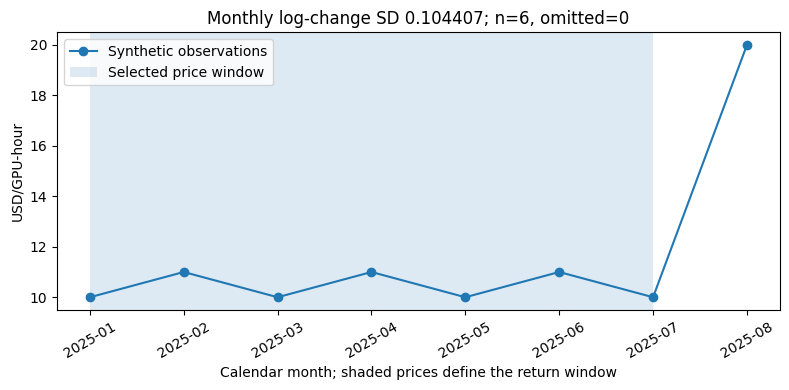

In [5]:
display(
    plot_observation_window(observations, start_month=january, end_month=january + 6)
)
explore_observation_window(observations, start_month=january, end_month=january + 6);

## Experiment 1 · Change the window

Compare January–July, before the jump, with May–August, containing it. Keep the same return definition and n−1 convention. The pre-jump sample has three positive and three negative changes of equal magnitude. The recent sample contains a positive small change, a negative small change and the large jump.

Shortening a window can either raise or lower a measured statistic; the direction depends on what observations enter and leave. Neither window is automatically the correct forecast horizon.

In [6]:
def window_estimate(start, end, source=returns):
    selected = [
        r.log_change for r in source if start <= r.start_month and r.end_month <= end
    ]
    return sample_volatility(selected)


pre_jump = window_estimate(january, january + 6)
recent = window_estimate(january + 4, january + 7)
show_finance_table(
    ["Price dates", "Valid changes", "Omitted", "Monthly sample SD"],
    [
        [
            "2025-01 through 2025-07",
            pre_jump.count,
            pre_jump.omitted_count,
            pre_jump.sample_sd,
        ],
        [
            "2025-05 through 2025-08",
            recent.count,
            recent.omitted_count,
            recent.sample_sd,
        ],
    ],
)
print(f"Pre-jump SD {pre_jump.sample_sd:.6f}; recent SD {recent.sample_sd:.6f}")

| Price dates | Valid changes | Omitted | Monthly sample SD |
| --- | --- | --- | --- |
| 2025-01 through 2025-07 | 6.00 | 0.00 | 0.10 |
| 2025-05 through 2025-08 | 3.00 | 0.00 | 0.41 |

Pre-jump SD 0.104407; recent SD 0.411382


The pre-jump SD is 0.104407 from six changes; the recent SD is 0.411382 from three. The large jump strongly affects this tiny sample. It may be a valid observation needing commercial context, not an automatic outlier to delete.

## Experiment 2 · Remove April's price

Set April to missing. March–April and April–May returns are now unavailable. Do not connect March directly to May and label that two-month change a monthly return. Likewise, do not forward-fill April or insert zero changes. We retain the calendar pairs and report the omissions.

In [7]:
missing_observations = tuple(
    MonthlyPrice(
        row.month_index,
        None if row.month_index == january + 3 else row.price_usd_per_gpu_hour,
    )
    for row in observations
)
missing_returns = monthly_log_returns(missing_observations)
missing_estimate = sample_volatility([r.log_change for r in missing_returns])
show_finance_table(
    ["Start", "End", "Log change", "Status"],
    [
        [
            month_label(r.start_month),
            month_label(r.end_month),
            r.log_change,
            r.missing_reason or "Observed pair",
        ]
        for r in missing_returns
    ],
)
print(
    f"Valid changes {missing_estimate.count}; omitted {missing_estimate.omitted_count}; SD {missing_estimate.sample_sd:.6f}"
)

| Start | End | Log change | Status |
| --- | --- | --- | --- |
| 2025-01 | 2025-02 | 0.10 | Observed pair |
| 2025-02 | 2025-03 | -0.10 | Observed pair |
| 2025-03 | 2025-04 | N/A | missing adjacent-month price |
| 2025-04 | 2025-05 | N/A | missing adjacent-month price |
| 2025-05 | 2025-06 | 0.10 | Observed pair |
| 2025-06 | 2025-07 | -0.10 | Observed pair |
| 2025-07 | 2025-08 | 0.69 | Observed pair |

Valid changes 5; omitted 2; SD 0.324306


Five changes remain and two are omitted; sample SD becomes 0.324306. Missingness changes the usable sample and may introduce selection bias. Reporting only the final statistic would hide those decisions.

## Experiment 3 · State the annualization convention

For comparable regular monthly changes, an illustrative annual scaling is sample SD × sqrt(12). Interpreting this as annual variability also assumes stable monthly variability and no serial covariance contribution. These assumptions are not established by eight synthetic prices.

We apply the scaling to the complete seven-change sample. Using 252 or 365 would import a different observation frequency. Multiplication changes the reporting scale; it adds neither observations nor predictive evidence.

In [8]:
annualized = sample_volatility([r.log_change for r in returns], periods_per_year=12)
direct_annualized = whole.sample_sd * sqrt(12)
show_finance_table(
    ["Quantity", "Value"],
    [
        ["Monthly SD", annualized.sample_sd],
        ["Periods per year assumed", 12],
        ["Direct annual scaling", direct_annualized],
        ["Shared annual scaling", annualized.annualized_sd],
    ],
)
print(f"Annualized under the stated assumptions: {annualized.annualized_sd:.6f}")

| Quantity | Value |
| --- | --- |
| Monthly SD | 0.28 |
| Periods per year assumed | 12.00 |
| Direct annual scaling | 0.97 |
| Shared annual scaling | 0.97 |

Annualized under the stated assumptions: 0.965734


The scaled result is 0.965734, or about 96.57% in log-return standard-deviation units. That is not a predicted annual price change or a guaranteed range. The large number follows from the invented jump and the chosen scaling assumptions.

## Document the measurement choices

The summary reuses the selected windows and missing-data case. Before comparing estimates, record dates, product definition, units, return convention, sample count and missing-data treatment. M4 scenarios and M6 model assumptions remain separate decisions; neither is silently calibrated from these results.

In [9]:
show_finance_table(
    ["Sample", "Valid", "Omitted", "Monthly SD"],
    [
        ["Whole synthetic history", whole.count, whole.omitted_count, whole.sample_sd],
        ["Pre-jump", pre_jump.count, pre_jump.omitted_count, pre_jump.sample_sd],
        ["Recent", recent.count, recent.omitted_count, recent.sample_sd],
        [
            "April missing",
            missing_estimate.count,
            missing_estimate.omitted_count,
            missing_estimate.sample_sd,
        ],
    ],
)

| Sample | Valid | Omitted | Monthly SD |
| --- | --- | --- | --- |
| Whole synthetic history | 7.00 | 0.00 | 0.28 |
| Pre-jump | 6.00 | 0.00 | 0.10 |
| Recent | 3.00 | 0.00 | 0.41 |
| April missing | 5.00 | 2.00 | 0.32 |

**Next:** E6 examines useful-output costs, or return to the core track. These sample estimates can inform an optional sensitivity discussion in the planned capstone, not replace its contractual inputs.

No real-data appendix is included. Actual history would require administrator provenance, dates, matching product definitions, units, redistribution permission and a checked-in snapshot. None of these synthetic prices are attributed to Ornn or another market source. Imputation, winsorization, stochastic simulation and pricing calibration remain outside this lesson.